# Mini-Project: AI Applied to Healthcare

**Team members:** ZAKI Ilias, SPENCER BAIDEN Brian, ABDELKAFI Amine  
**Course:** AI Health  
**Project scope:** compare two fundamentally different deep learning architectures on a healthcare dataset, including one Transformer-based model.


## 0. Colab Setup
Run this notebook on **Google Colab** with GPU enabled.


In [ ]:
!pip -q install tensorflow-datasets scikit-learn


## 1. Imports and Reproducibility


In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.19.0


## 2. Problem Definition and Dataset Context
We solve a **multi-class medical image classification** problem using `colorectal_histology` from TensorFlow Datasets.

- Domain: colorectal cancer histology tiles.
- Input: RGB image tile.
- Output: one class among 8 tissue categories.
- Learning type: supervised classification.

Source:
- https://www.tensorflow.org/datasets/catalog/colorectal_histology


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = 8

(ds_all, ds_info) = tfds.load(
    'colorectal_histology',
    split='train',
    as_supervised=True,
    with_info=True,
)

class_names = ds_info.features['label'].names
n_total = ds_info.splits['train'].num_examples

# Manual split required by project instructions: TFDS provides only one split for this dataset.
n_test = int(0.15 * n_total)
n_val = int(0.15 * n_total)
n_train = n_total - n_val - n_test

ds_all = ds_all.shuffle(n_total, seed=SEED, reshuffle_each_iteration=False)

ds_test = ds_all.take(n_test)
rest = ds_all.skip(n_test)
ds_val = rest.take(n_val)
ds_train = rest.skip(n_val)

print(f'Total: {n_total} | Train: {n_train} | Val: {n_val} | Test: {n_test}')
print('Classes:', class_names)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/colorectal_histology/incomplete.HBRPOI_2.0.0/colorectal_histology-train.tf…

Dataset colorectal_histology downloaded and prepared to /root/tensorflow_datasets/colorectal_histology/2.0.0. Subsequent calls will reuse this data.
Total: 5000 | Train: 3500 | Val: 750 | Test: 750
Classes: ['tumor', 'stroma', 'complex', 'lympho', 'debris', 'mucosa', 'adipose', 'empty']


## 3. Dataset Examples


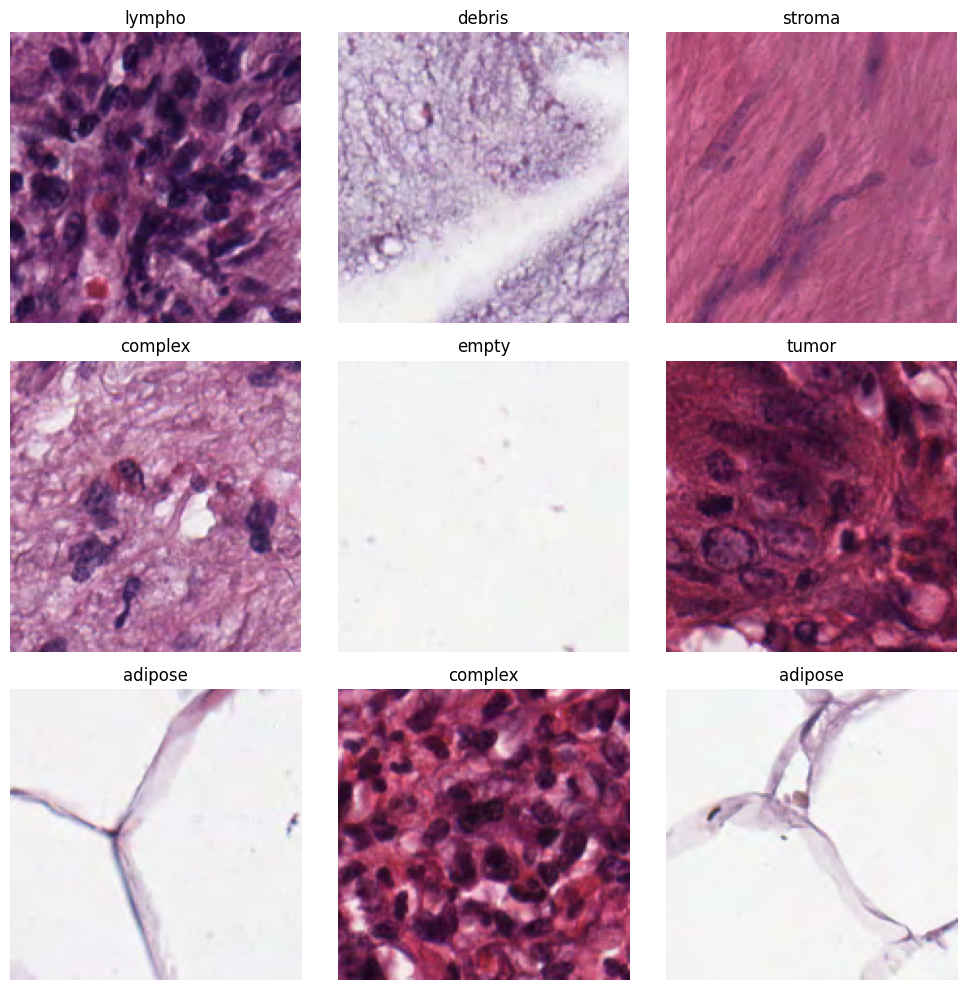

In [ ]:
plt.figure(figsize=(10, 10))
for i, (img, label) in enumerate(ds_train.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(class_names[int(label)])
    plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Preprocessing and Augmentation
Non-standard processing explained:
- Resize all images to `224x224`.
- Normalize pixel values to `[0, 1]`.
- Apply augmentation on training only (flip/rotation/zoom) to improve robustness.


In [ ]:
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.15),
], name='augmentation')


def preprocess_train(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    image = augment(image, training=True)
    return image, label


def preprocess_eval(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


ds_train = ds_train.map(preprocess_train, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_val = ds_val.map(preprocess_eval, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
ds_test = ds_test.map(preprocess_eval, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)


## 5. Model A: CNN (MobileNetV2 Transfer Learning)
**Rationale:** efficient convolutional baseline with pretrained features and low compute cost.


In [ ]:
def build_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    backbone = keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
    )
    backbone.trainable = False
    backbone._name = 'cnn_backbone'

    inputs = keras.Input(shape=input_shape)
    x = backbone(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='cnn_gap')(x)
    x = layers.Dropout(0.2, name='cnn_dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='cnn_classifier')(x)

    model = keras.Model(inputs, outputs, name='cnn_mobilenetv2')
    return model


cnn_model = build_cnn_model()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
cnn_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "cnn_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_gap                         │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_dropout (Dropout)           │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_classifier (Dense)          │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS_CNN = 8
callbacks_cnn = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('cnn_model.keras', monitor='val_accuracy', save_best_only=True),
]

history_cnn = cnn_model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_CNN, callbacks=callbacks_cnn)


Epoch 1/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 83s 570ms/step - accuracy: 0.5974 - loss: 1.1682 - val_accuracy: 0.8147 - val_loss: 0.5232
Epoch 2/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 39s 320ms/step - accuracy: 0.8097 - loss: 0.5257 - val_accuracy: 0.8400 - val_loss: 0.4442
Epoch 3/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 326ms/step - accuracy: 0.8403 - loss: 0.4535 - val_accuracy: 0.8627 - val_loss: 0.3931
Epoch 4/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 38s 304ms/step - accuracy: 0.8587 - loss: 0.3931 - val_accuracy: 0.8587 - val_loss: 0.3682
Epoch 5/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 317ms/step - accuracy: 0.8717 - loss: 0.3752 - val_accuracy: 0.8720 - val_loss: 0.3564
Epoch 6/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 35s 314ms/step - accuracy: 0.8827 - loss: 0.3524 - val_accuracy: 0.8787 - val_loss: 0.3407
Epoch 7/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 34s 303ms/step - accuracy: 0.8819 - loss: 0.3408 - val_accuracy: 0.8733 - val_loss: 0.3402
Epoch 8/8
110/110 ━━━━━━━━━━━━━━━━━━━━ 35s 320ms/step - accuracy: 0.8857 - loss: 0.3305 - 

## 6. Model B: ViT-like Transformer
**Rationale:** patch-based Transformer architecture to model global dependencies and satisfy the Transformer requirement.


In [ ]:
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patch) + self.position_embedding(positions)


def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


def build_vit_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    patch_size = 16
    num_patches = (input_shape[0] // patch_size) * (input_shape[1] // patch_size)
    projection_dim = 64
    transformer_layers = 6
    num_heads = 4

    inputs = keras.Input(shape=input_shape)
    patches = Patches(patch_size)(inputs)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=0.1)(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])

        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=[projection_dim * 2, projection_dim], dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.3)(representation)
    logits = layers.Dense(num_classes, activation='softmax')(representation)

    model = keras.Model(inputs=inputs, outputs=logits, name='vit_like')
    return model


vit_model = build_vit_model()
vit_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
vit_model.summary()


Model: "vit_like"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None, 768) │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 196, 64)   │     61,760 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 196, 64)   │        128 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 196, 128)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 196, 64)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 196, 64)   │          0 │ dropout_2[0][0],  │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 196, 64)   │          0 │ multi_head_atten… │
│                     │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 196, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 196, 128)  │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 196, 128)  │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 196, 64)   │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 661,448 (2.52 MB)

 Trainable params: 661,448 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS_VIT = 12
callbacks_vit = [
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('vit_model.keras', monitor='val_accuracy', save_best_only=True),
]

history_vit = vit_model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_VIT, callbacks=callbacks_vit)


Epoch 1/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 96s 540ms/step - accuracy: 0.2645 - loss: 3.7712 - val_accuracy: 0.3707 - val_loss: 1.7684
Epoch 2/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 337ms/step - accuracy: 0.4646 - loss: 1.4913 - val_accuracy: 0.5880 - val_loss: 1.0192
Epoch 3/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 337ms/step - accuracy: 0.5746 - loss: 1.1237 - val_accuracy: 0.6293 - val_loss: 0.9160
Epoch 4/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 326ms/step - accuracy: 0.6177 - loss: 1.0115 - val_accuracy: 0.6373 - val_loss: 1.0165
Epoch 5/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 42s 336ms/step - accuracy: 0.6563 - loss: 0.9499 - val_accuracy: 0.6867 - val_loss: 0.8873
Epoch 6/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 336ms/step - accuracy: 0.6805 - loss: 0.8827 - val_accuracy: 0.7440 - val_loss: 0.6895
Epoch 7/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 336ms/step - accuracy: 0.7482 - loss: 0.6837 - val_accuracy: 0.7733 - val_loss: 0.6022
Epoch 8/12
110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 333ms/step - accuracy: 0.7608 - loss: 0

## 7. Validation Comparison and Test Evaluation
Project rule: compare models on validation, then evaluate only the **best validation model** on test set.


In [ ]:
def evaluate_model(model, dataset, name='model'):
    y_true, y_pred = [], []

    for x_batch, y_batch in dataset:
        probs = model.predict(x_batch, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_true.extend(y_batch.numpy().tolist())
        y_pred.extend(preds.tolist())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    print(f'[{name}] Accuracy={acc:.4f} Precision={prec:.4f} Recall={rec:.4f} F1={f1:.4f}')
    return {
        'model': name,
        'accuracy': acc,
        'precision_macro': prec,
        'recall_macro': rec,
        'f1_macro': f1,
    }, y_true, y_pred


val_cnn, _, _ = evaluate_model(cnn_model, ds_val, name='CNN')
val_vit, _, _ = evaluate_model(vit_model, ds_val, name='ViT-like')

results = pd.DataFrame([val_cnn, val_vit]).sort_values('f1_macro', ascending=False)
results


[CNN] Accuracy=0.8880 Precision=0.8934 Recall=0.8901 F1=0.8900
[ViT-like] Accuracy=0.8360 Precision=0.8401 Recall=0.8386 F1=0.8370


,model,accuracy,precision_macro,recall_macro,f1_macro
0,CNN,0.888,0.893403,0.890094,0.890006
1,ViT-like,0.836,0.840132,0.838579,0.836954


In [ ]:
best_name = results.iloc[0]['model']
best_model = cnn_model if best_name == 'CNN' else vit_model

print('Best model by validation macro-F1:', best_name)
test_metrics, y_true_test, y_pred_test = evaluate_model(best_model, ds_test, name=f'{best_name} (test)')

print('\nClassification report (test):')
print(classification_report(y_true_test, y_pred_test, target_names=class_names, zero_division=0))


Best model by validation macro-F1: CNN
[CNN (test)] Accuracy=0.8853 Precision=0.8896 Recall=0.8914 F1=0.8887

Classification report (test):
              precision    recall  f1-score   support

       tumor       0.90      0.89      0.90        92
      stroma       0.85      0.77      0.81        98
     complex       0.80      0.75      0.77       107
      lympho       0.77      0.96      0.86        84
      debris       0.86      0.87      0.87        93
      mucosa       0.95      0.92      0.93       107
     adipose       0.98      0.99      0.98        93
       empty       1.00      0.99      0.99        76

    accuracy                           0.89       750
   macro avg       0.89      0.89      0.89       750
weighted avg       0.89      0.89      0.88       750



## 8. Explainability (Grad-CAM) for Classification
Grad-CAM is required for classification / many-to-one settings.


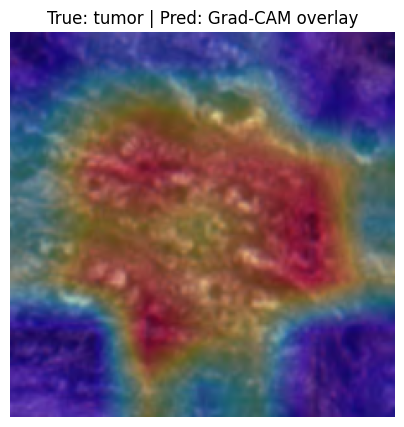

In [ ]:
def make_gradcam_heatmap(img_tensor, model):
    # Tensor feature map juste avant GlobalAveragePooling2D
    last_conv_tensor = model.get_layer('cnn_gap').input

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[last_conv_tensor, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_tensor, training=False)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]  # (H, W, C)
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


if 'CNN' in best_name:
    sample_img, sample_label = next(iter(ds_test.unbatch().batch(1)))
    heatmap = make_gradcam_heatmap(sample_img, cnn_model)

    plt.figure(figsize=(5, 5))
    plt.imshow(sample_img[0])
    plt.imshow(
        tf.image.resize(heatmap[..., None], (IMG_SIZE, IMG_SIZE))[..., 0],
        cmap='jet', alpha=0.35
    )
    plt.title(f"True: {class_names[int(sample_label[0])]} | Pred: Grad-CAM overlay")
    plt.axis('off')
    plt.show()
else:
    print('Best model is not CNN. Grad-CAM demonstration is provided on CNN model only.')

## 9. Curves, Confusion Matrix, and Discussion


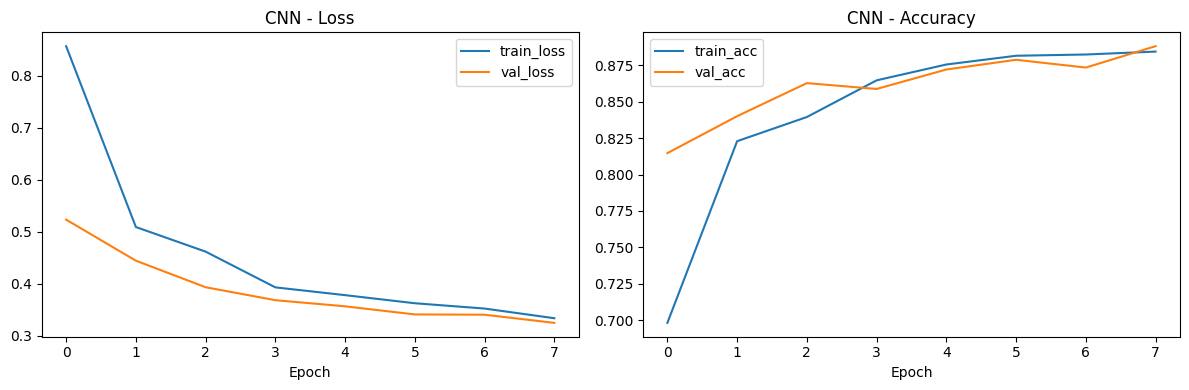

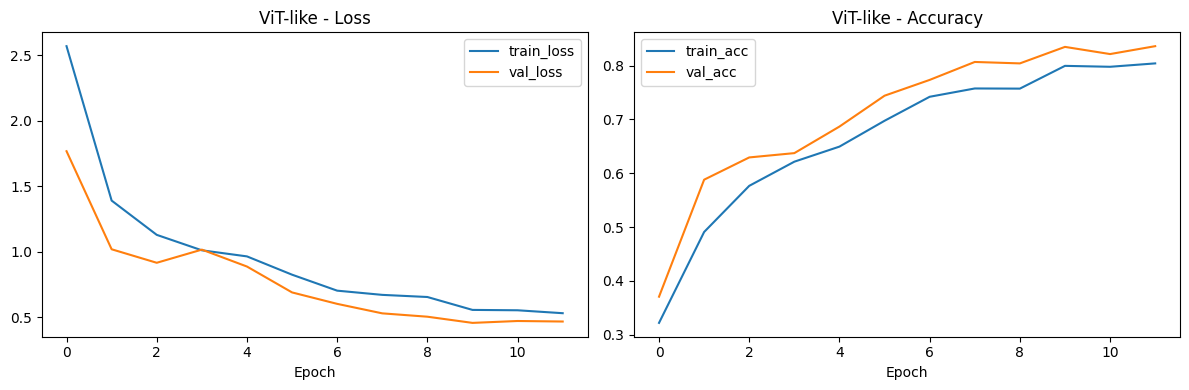

In [ ]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist['loss'], label='train_loss')
    axes[0].plot(hist['val_loss'], label='val_loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(hist['accuracy'], label='train_acc')
    axes[1].plot(hist['val_accuracy'], label='val_acc')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(history_cnn, 'CNN')
plot_history(history_vit, 'ViT-like')


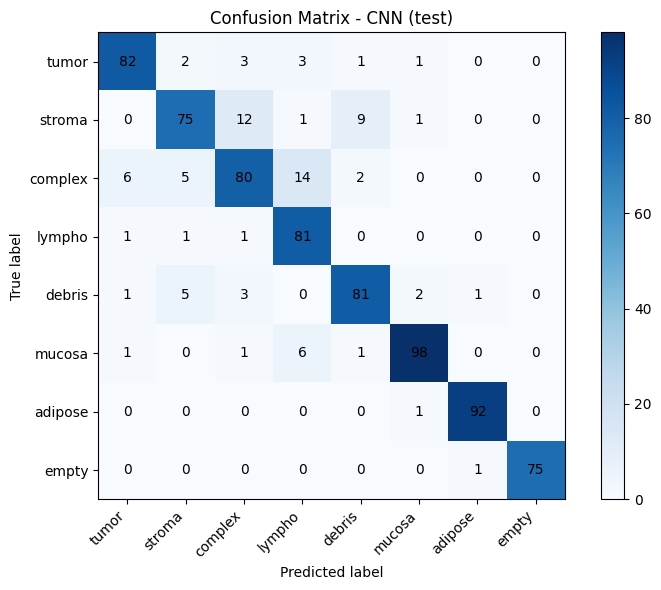

In [ ]:
cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix - {best_name} (test)')
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(range(len(class_names)), class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


## 10. Positioning Against State of the Art
- This notebook uses `colorectal_histology` (TFDS), an open benchmark derived from colorectal histology tiles.
- Because TFDS exposes a single split, our manual split differs from many published protocols.
- Therefore, direct score-to-score comparison should be interpreted carefully; still, we can compare trends and error patterns.
- If you choose a competition dataset later, add explicit leaderboard comparison here.


## 11. Save Model Weights


In [ ]:
cnn_model.save('cnn_model_final.keras')
vit_model.save('vit_model_final.keras')
print('Saved: cnn_model_final.keras and vit_model_final.keras')


Saved: cnn_model_final.keras and vit_model_final.keras


## 12. References
- TensorFlow Datasets: colorectal_histology  
  https://www.tensorflow.org/datasets/catalog/colorectal_histology
- TensorFlow / Keras API documentation  
  https://www.tensorflow.org/api_docs
- Grad-CAM: Selvaraju et al. (2017)  
  https://arxiv.org/abs/1610.02391
- Kather et al. colorectal histology context paper  
  https://doi.org/10.1371/journal.pmed.1002730


## 13. Build Final Submission ZIP
Run after training to create the upload file.


In [ ]:
import zipfile
from pathlib import Path

zip_name = 'ZAKI_Ilias_SPENCER_BAIDEN_Brian_ABDELKAFI_Amine.zip'
files = [
    Path('/content/cnn_model_final.keras'),
    Path('/content/vit_model_final.keras'),
]

with zipfile.ZipFile(zip_name, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for f in files:
        if not f.exists():
            raise FileNotFoundError(f'Missing file: {f}')
        zf.write(f, arcname=f.name)

print(f'Created {zip_name}')

Created ZAKI_Ilias_SPENCER_BAIDEN_Brian_ABDELKAFI_Amine.zip


In [ ]:
!ls -lh /content/*.keras /content/*.zip


-rw-r--r-- 1 root root 9.3M Mar  1 19:29 /content/cnn_model_final.keras
-rw-r--r-- 1 root root 9.3M Mar  1 19:20 /content/cnn_model.keras
-rw-r--r-- 1 root root 8.0M Mar  1 19:29 /content/vit_model_final.keras
-rw-r--r-- 1 root root 8.0M Mar  1 19:29 /content/vit_model.keras
-rw-r--r-- 1 root root  16M Mar  1 19:29 /content/ZAKI_Ilias_SPENCER_BAIDEN_Brian_ABDELKAFI_Amine.zip
